# Win-rate Beta Posterior (visualization)

Observed win_rate: 0.6500  (N_eff = 200 -> wins=130, losses=70)
Beta posterior: alpha=131, beta=71
Posterior mean = 0.6485
Posterior SD   = 0.0335
95% credible interval = [0.5815, 0.7127]
Sampled percentiles (1,5,10,50,90,95,99): [0.5683 0.5928 0.6054 0.6487 0.6912 0.7028 0.7221]


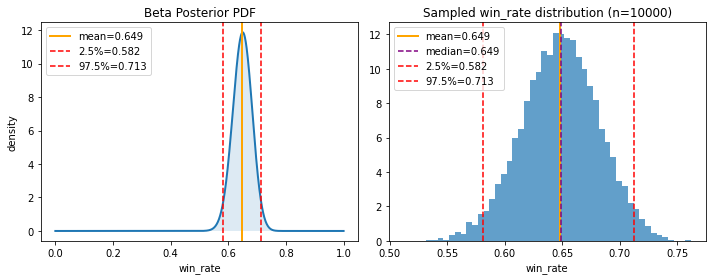

In [2]:
# Plot Beta posterior for observed win_rate
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist

def plot_winrate_beta_posterior(win_rate_obs=0.65, N_eff=200, samples=10000, figsize=(10,4)):
    """
    Plots Beta posterior given an observed win_rate and an effective sample size N_eff.
    Prints posterior mean, std, and 95% credible interval, and shows PDF + sampled histogram.
    """
    # turn observed win rate into wins/losses (effective counts)
    wins = int(round(win_rate_obs * N_eff))
    losses = int(round(N_eff - wins))
    alpha = 1 + wins
    beta_param = 1 + losses

    # analytic posterior stats
    post_mean = alpha / (alpha + beta_param)
    post_var = (alpha * beta_param) / ((alpha + beta_param)**2 * (alpha + beta_param + 1))
    post_sd = np.sqrt(post_var)
    ci_low, ci_high = beta_dist.ppf([0.025, 0.975], alpha, beta_param)

    # sample from posterior for histogram / Monte-Carlo usage
    sampled = beta_dist.rvs(alpha, beta_param, size=samples)

    # Print numbers
    print(f"Observed win_rate: {win_rate_obs:.4f}  (N_eff = {N_eff} -> wins={wins}, losses={losses})")
    print(f"Beta posterior: alpha={alpha}, beta={beta_param}")
    print(f"Posterior mean = {post_mean:.4f}")
    print(f"Posterior SD   = {post_sd:.4f}")
    print(f"95% credible interval = [{ci_low:.4f}, {ci_high:.4f}]")
    print("Sampled percentiles (1,5,10,50,90,95,99):", 
          np.round(np.percentile(sampled, [1,5,10,50,90,95,99]), 4))

    # Plot PDF + histogram
    x = np.linspace(0, 1, 1000)
    pdf = beta_dist.pdf(x, alpha, beta_param)

    fig, axes = plt.subplots(1,2, figsize=figsize)
    # PDF plot
    axes[0].plot(x, pdf, lw=2)
    axes[0].fill_between(x, 0, pdf, alpha=0.15)
    axes[0].axvline(post_mean, color='orange', lw=2, label=f"mean={post_mean:.3f}")
    axes[0].axvline(ci_low, color='red', ls='--', label=f"2.5%={ci_low:.3f}")
    axes[0].axvline(ci_high, color='red', ls='--', label=f"97.5%={ci_high:.3f}")
    axes[0].set_title("Beta Posterior PDF")
    axes[0].set_xlabel("win_rate")
    axes[0].set_ylabel("density")
    axes[0].legend()

    # Histogram of sampled win-rates
    axes[1].hist(sampled, bins=50, density=True, alpha=0.7)
    axes[1].axvline(post_mean, color='orange', lw=2, label=f"mean={post_mean:.3f}")
    axes[1].axvline(np.median(sampled), color='purple', lw=1.5, ls='--', label=f"median={np.median(sampled):.3f}")
    axes[1].axvline(ci_low, color='red', ls='--', label=f"2.5%={ci_low:.3f}")
    axes[1].axvline(ci_high, color='red', ls='--', label=f"97.5%={ci_high:.3f}")
    axes[1].set_title(f"Sampled win_rate distribution (n={samples})")
    axes[1].set_xlabel("win_rate")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# Example: use your observed win_rate and N_eff (change if you want)
plot_winrate_beta_posterior(win_rate_obs=0.65, N_eff=200, samples=10000)
